In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

import sklearn
sklearn.set_config(display='text')
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis # 선형 판별 분석 알고리즘을 사용하기 위해 import 한다.

선형 판변 분석(Linear Discriminant Analysis, LDA)

선형 판별 분석은 지도 학습적인 접근 방법을 통한 차원 축소 알고리즘으로 선형 판별 분석이라는 말의 뜻은 데이터 포인트가 속하는 클래스를 구분하는 판별 함수가 선형 형태의 함수라는 뜻이다.

데이터셋의 기존 공간으로 부터 집단간 분산과 집단내 분산의 비율을 최대화하는 기존 공간보다 더 작은 차원의 공간으로 원래 데이터를 투영시킴으로써 차원을 축소 한다. 즉, 데이터를 최대한 분리해주는 기능을 한다.

선형 판별 분석은 크게 3간게 과정을 거친다.  
① 집단단 거리를 계산한다. 이를 집간간 분산이라고 한다.  
② 각 집단의 평균과 각 데이터 포인트의 거리를 계산한다. 이를 집단내 분산이라고 한다.  
③ 기존 데이터셋의 공간보다 더 작은 차원의 공간을 만드는 것이다. 이 공간은 집단간 분산을 최대화하고 집단내 분산을 최소로 하는 공간이어야 한다.

와인 데이터를 사용해서 주성분 분석을 통해 차원을 축소해 본 후 차원을 축소하기 전과 차원을 축소한 후 정확도가 얼마나 달라지는지 알아본다.

In [2]:
# 데이터 불러오기
raw_data = datasets.load_wine() # 사이킷런 라이브러리가 제공하는 와인 데이터를 불러온다.
# print(raw_data)

# 피쳐, 레이블 데이터 저장
xData = raw_data.data # 피쳐 데이터를 저장한다.
yData = raw_data.target # 피쳐 데이터에 따른 레이블을 저장한다.
# print(xData.shape, yData.shape)

# 학습 데이터와 테스트 데이터로 분할
x_train, x_test, y_train, y_test = train_test_split(xData, yData, random_state=1)
# print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

# 데이터 표준화(정규화)
scaler = StandardScaler() # 표준화 스케일러 객체를 만든다.
x_train = scaler.fit_transform(x_train) # 학습 데이터를 표준화 스케일러로 표준화하고 적용한다.
x_test = scaler.transform(x_test) # 테스트 데이터를 학습 데이터로 표준화한 스케일러에 적용한다.

선형 판별 분석을 이용한 차원 축소

In [3]:
# n_components 속성값에 축소하려는 차원 크기를 지정하고 선형 판별 분석 모델을 만든다.
# n_components 속성값으로 사용 가능한 값은 기본값인 min(피쳐 개수, 클래스 개수 - 1)보다 큰 값을 지정할 수 없다.
# 와인 데이터의 피쳐는 13개이고 클래스는 3개이므로 n_components 속성값은 min(13, 3 - 1)의 결과인 2보다 큰 값을 지정하면 에러가 발생된다.
model_lda = LinearDiscriminantAnalysis(n_components=2)

# 선형 판별 분석은 지도 학습적인 접근 방법이므로 표준화 스케일러로 표준화한 학습 데이터와 학습 데이터에 따른 레이블을 넘겨서 학습시킨다.
# model_lda.fit(x_train, y_train)
# 학습된 선형 판별 분석 모델에 학습 데이터를 적용한다.
# x_train_lda = model_lda.transform(x_train)
x_train_lda = model_lda.fit_transform(x_train, y_train)

# 표준화 스케일러의 사용 방법과 마찬가지로 학습은 학습 데이터로만 해야하고 테스트 데이터는 학습 데이터로 학습된 결과에 적용만 시킨다.
x_test_lda = model_lda.transform(x_test)
print(x_train.shape, x_train_lda.shape, x_test.shape, x_test_lda.shape)

(133, 13) (133, 2) (45, 13) (45, 2)


In [4]:
# 선형 판별 분석 알고리즘을 학습 시킬때 지정한 학습 데이터에 따른 클래스 종류를 확인한다.
# classes_ 속성으로 클래스 종류를 확인 할 수 있다.
print(model_lda.classes_)

[0 1 2]


In [5]:
# 선형 판별 분석 상수항을 확인한다.
# intercept_ 속성으로 상수항을 확인할 수 있다.
print(model_lda.intercept_)

[ -9.49063922  -3.6792656  -10.65310672]


In [6]:
# 선형 판별 분석 가중 벡터를 확인한다.
# coef_ 속성으로 가중 벡터를 확인할 수 있다.
print(model_lda.coef_)

[[ 2.11536841  0.34171834  1.60756274 -2.62777005 -0.02954383 -1.92461007
   5.43612614  0.30142527 -0.66723405 -2.08948728  0.53569108  3.06011656
   5.45318503]
 [-1.18707715 -0.97635273 -1.64104916  1.19614378  0.22114803  0.2969019
   1.13721801  0.4338713   0.33425086 -1.57541361  0.56544507 -0.17730553
  -2.34856045]
 [-0.59547207  1.01875252  0.59754164  1.13544231 -0.28238675  1.65463974
  -7.48134065 -0.94177595  0.24492236  4.49319245 -1.38150969 -3.04974421
  -2.54627163]]


선형 판별 분석을 통해 차원 축소된 데이터 시각화

In [7]:
# 차원 축소된 데이터를 시각화 하기 위해서 데이터프레임을 만든다.
df = pd.DataFrame(x_train_lda, columns=['lda_x', 'lda_y'])
df['label'] = y_train
df

,lda_x,lda_y,label
0,-2.563293,-0.503212,0
1,-0.646015,-2.169761,1
2,-3.981901,1.621584,0
3,-5.956216,3.878140,0
4,-4.047839,2.335699,0
...,...,...,...
128,3.519877,0.440679,2
129,4.457515,0.491287,2
130,0.639263,-1.684700,1
131,2.440212,1.168633,2


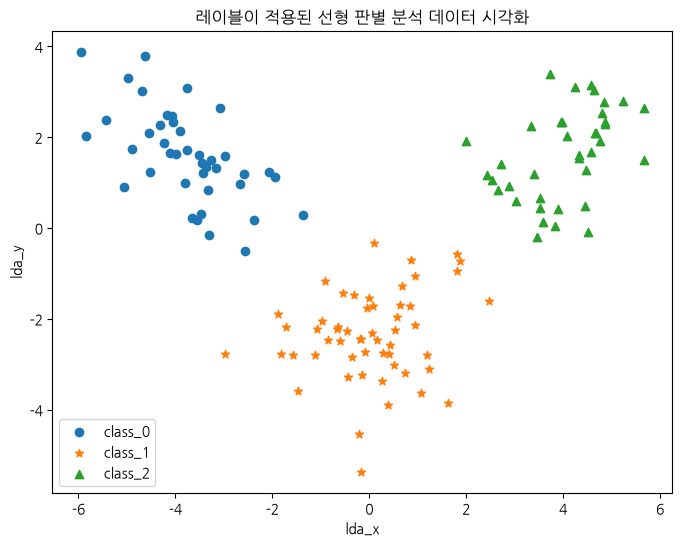

In [8]:
plt.figure(figsize=[8, 6])
markers = ['o', '*', '^']

for index, marker in enumerate(markers):
    df_index = df[df.label == index]
    label = raw_data.target_names[index]
    plt.scatter(x=df_index.lda_x, y=df_index.lda_y, marker=marker, label=label)

plt.title('레이블이 적용된 선형 판별 분석 데이터 시각화')
plt.xlabel('lda_x')
plt.ylabel('lda_y')
plt.legend()
plt.show()

선형 판별 분석 적용 전 데이터로 학습, 예측, 평가를 실행한다.

In [9]:
# 차원 축소가 되지 않은 학습 데이터(x_train)와 차원 축소가 되지 않은 학습 데이터에 따른 레이블(y_train)을 넘겨서 랜덤 포레스트 모델을 만들고 학습시킨다.
model = RandomForestClassifier(random_state=0, max_depth=2).fit(x_train, y_train)

In [10]:
# predict() 메소드의 인수로 차원 축소가 되지 않은 테스트 데이터(x_test)를 넘겨서 서포트 벡터 머신 모델을 예측한다.
predict = model.predict(x_test)
print(predict)

[2 1 0 1 0 2 1 0 2 1 0 0 1 0 1 1 2 0 1 0 0 1 2 0 0 2 0 0 0 2 1 2 2 0 1 1 1
 1 1 0 0 1 2 0 0]


In [11]:
# predict_proba() 메소드의 인수로 차원 축소가 되지 않은 테스트 데이터(x_test)를 넘겨서 각 클래스에 속할 확률로 예측한다.
predict_proba = model.predict_proba(x_test)
print(predict_proba)

[[0.06362204 0.27662898 0.65974899]
 [0.07527785 0.87944299 0.04527917]
 [0.68984851 0.23149516 0.07865633]
 [0.08605278 0.86203798 0.05190924]
 [0.85720867 0.12172218 0.02106915]
 [0.032829   0.2083631  0.7588079 ]
 [0.13843333 0.63448642 0.22708025]
 [0.85720867 0.12172218 0.02106915]
 [0.01684088 0.17892642 0.8042327 ]
 [0.03126683 0.86376109 0.10497208]
 [0.7449743  0.17077371 0.08425198]
 [0.46182976 0.41698592 0.12118432]
 [0.08779992 0.85888405 0.05331603]
 [0.8438832  0.12503028 0.03108652]
 [0.08436322 0.81247995 0.10315683]
 [0.03396126 0.9160399  0.04999884]
 [0.10772521 0.2818495  0.61042528]
 [0.77480273 0.19092476 0.0342725 ]
 [0.08009975 0.77564044 0.14425981]
 [0.8366743  0.13382925 0.02949646]
 [0.85079023 0.12771509 0.02149468]
 [0.25611351 0.54744938 0.19643711]
 [0.06944088 0.21842478 0.71213434]
 [0.65358728 0.33730652 0.00910619]
 [0.68868517 0.26564099 0.04567383]
 [0.06833558 0.30731826 0.62434616]
 [0.84183189 0.13667343 0.02149468]
 [0.81741427 0.15772108 0.02

In [12]:
# 혼동 행렬
# confusion_matrix() 함수의 인수로 테스트 데이터의 레이블(y_test)과 예측값(predict)을 순서대로 넘겨서 혼동 행렬을 출력한다.
confusion = confusion_matrix(y_test, predict)
print(confusion)

[[18  0  0]
 [ 1 16  0]
 [ 0  0 10]]


In [13]:
# 분류 리포트
# classification_report() 함수의 인수로 테스트 데이터의 레이블(y_test)과 예측값(predict)을 순서대로 넘겨서 분류 리포트를 출력한다.
classification = classification_report(y_test, predict, target_names=raw_data.target_names)
print(classification)

              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        18
     class_1       1.00      0.94      0.97        17
     class_2       1.00      1.00      1.00        10

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



선형 판별 분석 적용 후 데이터로 학습, 예측, 평가를 실행한다.

In [14]:
# 차원 축소가 된 학습 데이터(x_train_lda)와 차원 축소가 된 학습 데이터에 따른 레이블(y_train)을 넘겨서 앙상블 랜덤 포레스트 모델을 만들고 학습시킨다.
model.fit(x_train_lda, y_train)

RandomForestClassifier(max_depth=2, random_state=0)

In [15]:
# predict() 메소드의 인수로 차원 축소가 된 테스트 데이터(x_test_lda)를 넘겨서 서포트 벡터 머신 모델을 예측한다.
predict = model.predict(x_test_lda)
print(predict)

[2 1 0 1 0 2 1 0 2 1 0 0 1 0 1 1 2 0 1 0 0 1 2 1 0 2 0 0 0 2 1 2 2 0 1 1 1
 1 1 0 0 1 2 0 0]


In [17]:
# predict_proba() 메소드의 인수로 차원 축소가 되지 않은 테스트 데이터(x_test_lda)를 넘겨서 각 클래스에 속할 확률로 예측한다.
predict_proba = model.predict_proba(x_test_lda)
print(predict_proba)

[[0.10859123 0.00242995 0.88897882]
 [0.00609793 0.99229782 0.00160425]
 [0.88255788 0.0039751  0.11346702]
 [0.00609793 0.99229782 0.00160425]
 [0.878402   0.0039751  0.1176229 ]
 [0.11269337 0.00267995 0.88462668]
 [0.09411876 0.8917502  0.01413104]
 [0.89446261 0.00385605 0.10168134]
 [0.11269337 0.00267995 0.88462668]
 [0.00609793 0.99229782 0.00160425]
 [0.8771502  0.0039751  0.1188747 ]
 [0.53003644 0.27571986 0.1942437 ]
 [0.00609793 0.99229782 0.00160425]
 [0.8796502  0.0039751  0.1163747 ]
 [0.00609793 0.99229782 0.00160425]
 [0.00609793 0.99229782 0.00160425]
 [0.11617766 0.00433261 0.87948973]
 [0.86091213 0.03510995 0.10397792]
 [0.00609793 0.99229782 0.00160425]
 [0.8796502  0.0039751  0.1163747 ]
 [0.8796502  0.0039751  0.1163747 ]
 [0.00609793 0.99229782 0.00160425]
 [0.14157888 0.15413556 0.70428556]
 [0.20382748 0.79511522 0.0010573 ]
 [0.83590552 0.03510995 0.12898453]
 [0.10589422 0.00267995 0.89142583]
 [0.87986087 0.0042251  0.11591403]
 [0.88666002 0.0042251  0.10

In [18]:
# 혼동 행렬
# confusion_matrix() 함수의 인수로 테스트 데이터의 레이블(y_test)과 예측값(predict)을 순서대로 넘겨서 혼동 행렬을 출력한다.
confusion = confusion_matrix(y_test, predict)
print(confusion)

[[18  0  0]
 [ 0 17  0]
 [ 0  0 10]]


In [19]:
# 분류 리포트
# classification_report() 함수의 인수로 테스트 데이터의 레이블(y_test)과 예측값(predict)을 순서대로 넘겨서 분류 리포트를 출력한다.
classification = classification_report(y_test, predict, target_names=raw_data.target_names)
print(classification)

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        17
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

